Using device: cuda
Running in Google Colab
Drive already mounted at /content/gdrive/; to attempt to forcibly remount, call drive.mount("/content/gdrive/", force_remount=True).
Loading data...
Train: (44903, 3), Val: (9624, 3), Test: (9622, 3)

Label mapping: {0: 'Anxiety/Stress', 1: 'Bipolar/Personality', 2: 'Depressive_Spectrum', 3: 'Normal'}
Number of classes: 4

Loading tokenizer: t5-base
Tokenizing datasets...


Map:   0%|          | 0/44903 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4118: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/9624 [00:00<?, ? examples/s]

Map:   0%|          | 0/9622 [00:00<?, ? examples/s]

...

/tmp/ipython-input-118393833.py:404: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(



Starting Training - 5 epochs
Start time: 2025-12-02 13:46:34


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 Macro,F1 Weighted
1,0.081600,0.085641,0.919057,0.920693,0.919060,0.919078,0.919079
2,0.051700,0.054361,0.948878,0.949840,0.948879,0.948969,0.948967
3,0.031100,0.044611,0.966542,0.966768,0.966547,0.966491,0.966489
4,0.010000,0.048879,0.970075,0.970276,0.970080,0.970013,0.970011
5,0.030800,0.047764,0.971114,0.971240,0.971119,0.971037,0.971035


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].



End time: 2025-12-02 16:03:40
Training duration: 2h 17m 5s

💾 Model and tokenizer saved to: /content/gdrive/MyDrive/Colab Notebooks/d266/FinalProject/t5base_finetuned_mentalhealth

FINAL EVALUATION

Evaluating on Validation Set
Processing 9624 samples in batches of 16...
  Processed 16/9624 samples
  Processed 176/9624 samples
  Processed 336/9624 samples
  Processed 496/9624 samples
  Processed 656/9624 samples
  Processed 816/9624 samples
  Processed 976/9624 samples
  Processed 1136/9624 samples
  Processed 1296/9624 samples
  Processed 1456/9624 samples
  Processed 1616/9624 samples
  Processed 1776/9624 samples
  Processed 1936/9624 samples
  Processed 2096/9624 samples
  Processed 2256/9624 samples
  Processed 2416/9624 samples
  Processed 2576/9624 samples
  Processed 2736/9624 samples
  Processed 2896/9624 samples
  Processed 3056/9624 samples
  Processed 3216/9624 samples
  Processed 3376/9624 samples
  Processed 3536/9624 samples
  Processed 3696/9624 samples
  Processed 385

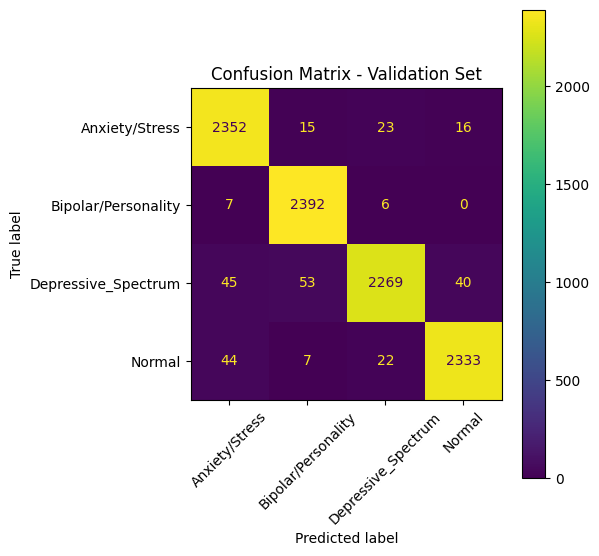

💾 Predictions saved to: /content/gdrive/MyDrive/Colab Notebooks/d266/FinalProject/predictions_validation.csv

Evaluating on Test Set
Processing 9622 samples in batches of 16...
  Processed 16/9622 samples
  Processed 176/9622 samples
  Processed 336/9622 samples
  Processed 496/9622 samples
  Processed 656/9622 samples
  Processed 816/9622 samples
  Processed 976/9622 samples
  Processed 1136/9622 samples
  Processed 1296/9622 samples
  Processed 1456/9622 samples
  Processed 1616/9622 samples
  Processed 1776/9622 samples
  Processed 1936/9622 samples
  Processed 2096/9622 samples
  Processed 2256/9622 samples
  Processed 2416/9622 samples
  Processed 2576/9622 samples
  Processed 2736/9622 samples
  Processed 2896/9622 samples
  Processed 3056/9622 samples
  Processed 3216/9622 samples
  Processed 3376/9622 samples
  Processed 3536/9622 samples
  Processed 3696/9622 samples
  Processed 3856/9622 samples
  Processed 4016/9622 samples
  Processed 4176/9622 samples
  Processed 4336/9622

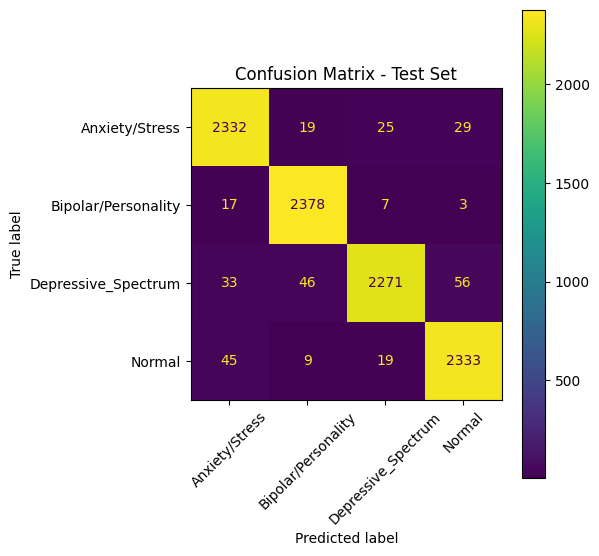

💾 Predictions saved to: /content/gdrive/MyDrive/Colab Notebooks/d266/FinalProject/predictions_test.csv

✅ Evaluation Complete!

📁 All results saved in: /content/gdrive/MyDrive/Colab Notebooks/d266/FinalProject/

📊 Files created:
  - confusion_matrix_validation.png
  - confusion_matrix_test.png
  - predictions_validation.csv
  - predictions_test.csv
  - Model: /content/gdrive/MyDrive/Colab Notebooks/d266/FinalProject/t5base_finetuned_mentalhealth

🎯 Final Results:
  Validation Accuracy: 0.9711
  Test Accuracy: 0.9680


In [ ]:
# -*- coding: utf-8 -*-
"""
Mental health posts — T5 fine-tuning and evaluation

End-to-end Colab-oriented workflow: load CSV splits, tokenize, fine-tune t5-base (or configured
checkpoint), evaluate on validation and test, and save confusion matrices / predictions.
"""

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
)
import torch
from torch.utils.data import DataLoader
import os
from datetime import datetime

os.environ["WANDB_DISABLED"] = "true"


# CONFIGURATION

dryRun = False  # Set to True for testing with small dataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Detect environment
if os.getenv("KAGGLE_KERNEL_RUN_TYPE"):
    print("Running in Kaggle")
    ENV = "kaggle"
elif os.getenv("COLAB_RELEASE_TAG"):
    print("Running in Google Colab")
    ENV = "colab"
else:
    print("Running locally")
    ENV = "local"

# Set base directory
if ENV == "colab":
    from google.colab import drive
    drive.mount('/content/gdrive/')
    base_dir = "/content/gdrive/MyDrive/Colab Notebooks/d266/FinalProject/"
elif ENV == "kaggle":
    base_dir = "/kaggle/working/"
else:
    base_dir = "./"


# DATA LOADING

def load_data(env, base_dir):
    """Load data based on environment"""
    if env == "kaggle":
        import kagglehub
        from kagglehub import KaggleDatasetAdapter

        train_df = kagglehub.load_dataset(
            KaggleDatasetAdapter.PANDAS, "kitushan/mental-health", "train_balanced.csv"
        )
        test_df = kagglehub.load_dataset(
            KaggleDatasetAdapter.PANDAS, "kitushan/mental-health", "test.csv"
        )
        val_df = kagglehub.load_dataset(
            KaggleDatasetAdapter.PANDAS, "kitushan/mental-health", "val.csv"
        )
    else:
        train_df = pd.read_csv(base_dir + "train_balanced.csv")
        val_df = pd.read_csv(base_dir + "val.csv")
        test_df = pd.read_csv(base_dir + "test.csv")

    # Rename and clean
    train_df = train_df.rename(columns={"statement": "text"}).dropna()
    val_df = val_df.rename(columns={"statement": "text"}).dropna()
    test_df = test_df.rename(columns={"statement": "text"}).dropna()

    return train_df, val_df, test_df

def clean_text(text):
    """Clean and normalize text"""
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"['\"`]", "", text)
    text = re.sub(r"[^a-z0-9.,!?;:() ]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

print("Loading data...")
train_df, val_df, test_df = load_data(ENV, base_dir)

# Clean text
train_df['text'] = train_df['text'].apply(clean_text)
val_df['text'] = val_df['text'].apply(clean_text)
test_df['text'] = test_df['text'].apply(clean_text)

print(f"Train: {train_df.shape}, Val: {val_df.shape}, Test: {test_df.shape}")


# LABEL ENCODING

le = LabelEncoder()
train_df['labels'] = le.fit_transform(train_df['status_combined'])
val_df['labels'] = le.transform(val_df['status_combined'])
test_df['labels'] = le.transform(test_df['status_combined'])

# Create label mappings
id2label = {i: label for i, label in enumerate(le.classes_)}
label2id = {label: i for i, label in enumerate(le.classes_)}
num_labels = len(le.classes_)

print(f"\nLabel mapping: {id2label}")
print(f"Number of classes: {num_labels}")

# Convert labels to strings for T5
train_df['labels'] = train_df['labels'].astype(str)
val_df['labels'] = val_df['labels'].astype(str)
test_df['labels'] = test_df['labels'].astype(str)


# CREATE DATASETS

train_ds = Dataset.from_pandas(train_df[["text", "labels"]])
val_ds = Dataset.from_pandas(val_df[["text", "labels"]])
test_ds = Dataset.from_pandas(test_df[["text", "labels"]])


# TOKENIZATION

model_name = "t5-base"
print(f"\nLoading tokenizer: {model_name}")
tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess_function(examples):
    """Preprocess examples for T5"""
    # Create input prompts
    inputs = [
        f"classify mental health: {text}"
        for text in examples["text"]
    ]

    # Tokenize inputs
    model_inputs = tokenizer(
        inputs,
        max_length=128,
        truncation=True,
        padding="max_length"  # Changed: pad to max_length
    )

    # Tokenize labels - T5 needs labels as input_ids
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(
            examples["labels"],
            max_length=3,
            truncation=True,
            padding="max_length"  # Changed: pad to max_length
        )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

print("Tokenizing datasets...")
tokenized_train = train_ds.map(preprocess_function, batched=True)
tokenized_val = val_ds.map(preprocess_function, batched=True)
tokenized_test = test_ds.map(preprocess_function, batched=True)
dryRun = False
# Dry run configuration
if dryRun:
    print("\n DRY RUN MODE - Using small dataset")
    tokenized_train = tokenized_train.select(range(1000))  # At least 1000
    tokenized_val = tokenized_val.select(range(200))
    tokenized_test = tokenized_test.select(range(200))
    num_train_epochs = 3  # At least 3 epochs
    train_batch_size = 4
    eval_batch_size = 4
else:
    num_train_epochs = 5
    train_batch_size = 8
    eval_batch_size = 16


# MODEL SETUP

print(f"\nLoading model: {model_name}")
model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)


# EVALUATION FUNCTIONS

def compute_metrics(eval_pred):
    """Compute metrics during training"""
    predictions, labels = eval_pred

    # Decode predictions and labels
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)

    # Replace -100 in labels (used for padding)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # Clean and validate
    decoded_preds = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]

    # Calculate metrics
    accuracy = accuracy_score(decoded_labels, decoded_preds)
    precision = precision_score(decoded_labels, decoded_preds, average="macro", zero_division=0)
    recall = recall_score(decoded_labels, decoded_preds, average="macro", zero_division=0)
    f1_macro = f1_score(decoded_labels, decoded_preds, average="macro", zero_division=0)
    f1_weighted = f1_score(decoded_labels, decoded_preds, average="weighted", zero_division=0)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }

def evaluate_and_plot(model, tokenizer, dataset, dataset_name, id2label, device, batch_size=16):
    """
    Evaluate model and create confusion matrix using direct generation

    Args:
        model: The T5 model
        tokenizer: The tokenizer
        dataset: Tokenized dataset to evaluate
        dataset_name: Name for the plot title (e.g., "Validation", "Test")
        id2label: Dictionary mapping label IDs to label names
        device: torch device
        batch_size: Batch size for evaluation
    """
    print(f"\n{'='*60}")
    print(f"Evaluating on {dataset_name} Set")
    print(f"{'='*60}")

    model.eval()

    decoded_preds = []
    decoded_labels = []

    print(f"Processing {len(dataset)} samples in batches of {batch_size}...")

    # Process in batches manually
    with torch.no_grad():
        for i in range(0, len(dataset), batch_size):
            batch_end = min(i + batch_size, len(dataset))
            batch_indices = range(i, batch_end)

            # Get batch data
            batch_input_ids = [dataset[j]['input_ids'] for j in batch_indices]
            batch_attention_mask = [dataset[j]['attention_mask'] for j in batch_indices]
            batch_labels = [dataset[j]['labels'] for j in batch_indices]

            # Convert to tensors
            input_ids = torch.tensor(batch_input_ids).to(device)
            attention_mask = torch.tensor(batch_attention_mask).to(device)

            # Generate predictions
            generated_ids = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_length=3,
                num_beams=1,
                do_sample=False,
            )

            # Decode predictions
            batch_preds = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
            decoded_preds.extend([p.strip() for p in batch_preds])

            # Decode labels
            for label_seq in batch_labels:
                # Filter out -100 and padding tokens
                label_seq_clean = [int(t) for t in label_seq if t not in [-100, tokenizer.pad_token_id]]
                if label_seq_clean:
                    label_text = tokenizer.decode(label_seq_clean, skip_special_tokens=True)
                    decoded_labels.append(label_text.strip())
                else:
                    decoded_labels.append("")

            if (i // batch_size) % 10 == 0:
                print(f"  Processed {batch_end}/{len(dataset)} samples")

    # Debug: Print first few predictions
    print(f"\n Sample predictions:")
    for i in range(min(10, len(decoded_preds))):
        print(f"  True: {decoded_labels[i]}, Predicted: {decoded_preds[i]}")

    # Print metrics
    print(f"\n{dataset_name} Metrics:")
    print(f"Total samples: {len(decoded_labels)}")

    # Count valid predictions
    valid_pred_count = sum(1 for p in decoded_preds if p.isdigit())
    invalid_pred_count = len(decoded_preds) - valid_pred_count
    print(f"Valid predictions: {valid_pred_count}")
    print(f"Invalid predictions: {invalid_pred_count}")

    if invalid_pred_count > 0:
        print(f"\nInvalid prediction examples: {[p for p in decoded_preds if not p.isdigit()][:5]}")

    # Filter valid predictions for metrics
    valid_indices = [i for i, p in enumerate(decoded_preds) if p.isdigit() and decoded_labels[i].isdigit()]

    if len(valid_indices) == 0:
        print(" ERROR: No valid predictions found!")
        print("This usually means the model is not generating properly.")
        print("Check:")
        print("  1. Model was trained with predict_with_generate=True")
        print("  2. Generation parameters are correct")
        print("  3. Labels are properly formatted during training")
        return None, None, None

    valid_true = [decoded_labels[i] for i in valid_indices]
    valid_pred = [decoded_preds[i] for i in valid_indices]

    print(f"\nAccuracy: {accuracy_score(valid_true, valid_pred):.4f}")
    print(f"\nClassification Report:")
    print(classification_report(
        valid_true,
        valid_pred,
        labels=[str(i) for i in range(num_labels)],
        target_names=[id2label[i] for i in range(num_labels)],
        zero_division=0
    ))

    # Create confusion matrix
    y_true_valid = [int(l) for l in valid_true]
    y_pred_valid = [int(p) for p in valid_pred]

    cm = confusion_matrix(
        y_true_valid,
        y_pred_valid,
        labels=list(range(num_labels))
    )

    # Plot confusion matrix
    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[id2label[i] for i in range(num_labels)]
    )
    disp.plot( ax=ax, xticks_rotation=45)#cmap="Blues",
    plt.title(f"Confusion Matrix - {dataset_name} Set")
    plt.tight_layout()

    save_path = base_dir + f"confusion_matrix_{dataset_name.lower()}.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\n Confusion matrix saved to: {save_path}")
    plt.show()

    # Save detailed results
    results_df = pd.DataFrame({
        'True_Label': valid_true,
        'Predicted_Label': valid_pred,
        'True_Label_Name': [id2label[int(l)] for l in valid_true],
        'Predicted_Label_Name': [id2label[int(p)] for p in valid_pred],
    })

    csv_path = base_dir + f"predictions_{dataset_name.lower()}.csv"
    results_df.to_csv(csv_path, index=False)
    print(f" Predictions saved to: {csv_path}")

    return y_true_valid, y_pred_valid, results_df


# TRAINING

training_args = Seq2SeqTrainingArguments(
    output_dir=base_dir + "t5_classification",
    seed=42,
    per_device_train_batch_size=train_batch_size,
    per_device_eval_batch_size=eval_batch_size,
    num_train_epochs=num_train_epochs,
    learning_rate=5e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,
    gradient_accumulation_steps=2,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    logging_dir=base_dir + "logs",
    logging_steps=10,
    predict_with_generate=True,
    generation_max_length=3,
    generation_num_beams=1,
    report_to="none",
    push_to_hub=False,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

print(f"\n{'='*60}")
print(f"Starting Training - {num_train_epochs} epochs")
print(f"{'='*60}")

start_time = datetime.now()
print(f"Start time: {start_time.strftime('%Y-%m-%d %H:%M:%S')}")

# Train
trainer.train()

end_time = datetime.now()
duration = end_time - start_time
hours, remainder = divmod(duration.total_seconds(), 3600)
minutes, seconds = divmod(remainder, 60)

print(f"\nEnd time: {end_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Training duration: {int(hours)}h {int(minutes)}m {int(seconds)}s")


# SAVE MODEL

model_save_path = base_dir + "t5base_finetuned_mentalhealth"
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)
print(f"\n Model and tokenizer saved to: {model_save_path}")


# EVALUATION

print("\n" + "="*60)
print("FINAL EVALUATION")
print("="*60)

# Get the best model from trainer
best_model = trainer.model

# Evaluate on validation set
y_true_val, y_pred_val, val_results = evaluate_and_plot(
    best_model, tokenizer, tokenized_val, "Validation", id2label, device, eval_batch_size
)

# Evaluate on test set
y_true_test, y_pred_test, test_results = evaluate_and_plot(
    best_model, tokenizer, tokenized_test, "Test", id2label, device, eval_batch_size
)

print(f"\n{'='*60}")
print(" Evaluation Complete!")
print(f"{'='*60}")
print(f"\n All results saved in: {base_dir}")
print("\n Files created:")
print("  - confusion_matrix_validation.png")
print("  - confusion_matrix_test.png")
print("  - predictions_validation.csv")
print("  - predictions_test.csv")
print(f"  - Model: {model_save_path}")

if y_true_val is not None and y_true_test is not None:
    print(f" Final Results:")
    print(f"  Validation Accuracy: {accuracy_score([str(y) for y in y_true_val], [str(y) for y in y_pred_val]):.4f}")
    print(f"  Test Accuracy: {accuracy_score([str(y) for y in y_true_test], [str(y) for y in y_pred_test]):.4f}")

## Notebook layout

The runnable **training and evaluation** logic is consolidated in the code cell above so it can run end-to-end in Google Colab. Use the **CONFIGURATION** block inside that cell for paths, `dryRun`, and model names.